# Solving the head equation
In the following script we will solve the heat equation on complex geometry objects using finite element methods from DOLFINx. to accomplish this. We will first build a working minimal version in this jupyter notebook before translating the methods into a proper python script. We will aim to simulate a block of Tofu inside a cast iron skillet, heated from the bottom. Further we will try to generalize our code to such a degree, that we can load in objects to put in the pan.
## Arriving at the variational problem
To solve the heat equation we shall first take a look at the original PDE to solve. this is given by
$$
\begin{equation}
\begin{aligned}
\rho c \frac{\partial u}{\partial t} & = k  \nabla^2u + f  \qquad &\text{on } \Omega\times (0,T],\\
k \frac{\partial u}{\partial n} & = h \left(u-u_\text{env}\right)+\epsilon \sigma \left(u^4-u_\text{env}^4\right)\qquad &\text{on } \partial\Omega\times (0,T],\\
u & = u_0  \qquad &\text{at } t=0.
\end{aligned}
\end{equation}\tag{1}
$$
Here $u$ is a function of spatial coordinates $x$ and time $t$. The Domain $\Omega$ is the object on which the heat equation shall be solved, $n$ is the outward pointing normal vector on the domain, while $u_0$ is the function of the initial temperature distrbution at $t=0$. $f$ is a volume heat term, we will formally keep it in our equation for now but we need to remind ourselves that the pan does not have an integrated heater, so in the end $f=0$ for our pan. Yet there might be chemical reactions going on in the food that we cook so in general $f\neq 0$ inside that object. 
On the surface we include radiative and convection losses to the environment, where $u_\text{env}$ is the temperature of the environment. However whe should keep in mind, that this environment also includes the hot-plate at some point so we will split the surface of the domain in parts where it interacts with the hot-plate $\partial \Omega_\text{hp}$ and the free part $\partial \Omega_\text{free}$. Last but not least we shall shortly define all physical parameters:
$\rho$ is the density of the pan, $c$ is its heat coefficient, $k$ the thermal cunductivity, $h$ the convection transfer coefficient, $\epsilon$ the emissivity and $\sigma$ the Stefan-Boltzman constant. For ease of notation we define
$$\alpha:=\frac{k}{\rho c},\qquad \beta = \frac{h}{\rho c} \qquad \text{and} \qquad \gamma = \frac{\epsilon \sigma}{\rho c}$$
Further we shall scale $f \to f / (\rho c)$.

We will handle the time derivative by discretizing the problem into steps at points in time $t_n$. The PDE in discretized form can then be given by
$$\left(\frac{\partial u}{\partial t}\right)^n = \alpha \nabla^2 u^{n} + f^n,$$
where the index $n$ conveys that $u^n=u(x,t_n)$ is evaluated at a certain time. There is now the option to approximate the time derivative as the difference of $u$ between time steps. We write
$$\left(\frac{\partial u}{\partial t}\right)^{n+1}\approx\frac{u^{n+1}-u^n}{\Delta t}$$
and plug this into the expression above to obtain
$$\frac{u^{n+1}-u^n}{\Delta t} = \alpha\nabla^2 u^{n+1} + f^{n+1},$$
with its boundary condition of $u^0=u_0$. We reorder this equation and split in into a part only containing functions dependent on $u^{n+1}$ and a part with all remaining functions:
$$u^{n+1}-\alpha \Delta t \nabla^2 u^{n+1} - u^n - \Delta t f^{n+1}=0, \qquad \text{ for } n=1,2,3,\dots. \tag{2}$$
This makes it abbundandly clear, that we can solve this problem as iterative stationary problems. After solving it for a certain time point $t_n$ we can then obtain the solution for $t_{n+1}$ by plugging into the equation again.

At this point the variational form of these problems is easy to obtain by multiplying (2) by a test function $v$ and intergating over the domain $\Omega$
$$ \int_\Omega vu^{n+1}-\alpha \Delta t v \nabla^2 u^{n+1} - v u^n - \Delta t v f^{n+1} \mathrm{d} V=\text{const.}$$
We will now use integration by parts to obtain

$$\int_\Omega v u^{n+1}+ \alpha \Delta t (\nabla u^{n+1})\cdot(\nabla v) - v u^n - \Delta t v f^{n+1}\mathrm{d}V - \int_{\partial \Omega} \Delta t \alpha v n\cdot(\nabla u^{n+1}) \mathrm{d} S = \text{const.}$$
This can now be split up into a linear and bilinear part with

$$ \begin{equation}
\begin{aligned}
a(u^{n+1},v)&= \int_\Omega v u^{n+1} + \alpha \Delta t (\nabla u^{n+1}) \cdot (\nabla v) \mathrm{d} V\\
&-\int_{\partial \Omega} (\Delta t \beta) v u^{n+1} + (\Delta t \gamma) v (u^{n+1})^4 \mathrm{d}S\\
L_{n+1}(v)&=\int_\Omega v u^n + \Delta t v f^{n+1}\mathrm{d} V\\
&+\int_{\partial \Omega} (\Delta t \beta) v u_\text{env} + (\Delta t \gamma) v (u_\text{env})^4 \mathrm{d}S\\
\end{aligned}
\end{equation}$$
We now have to solve the variational problem 
$a(u^{n+1},v) = L_{n+1}(v) \quad \forall  v \in V$ with $V$ the vector space of functions on our domain. We notice that this problem is non linear on accord of the radiation term.

## Humble beginnings
We shall start with solving the heat-equation for a simple object, box with length $d$ which shall be heated from the bottom. We will for now ignore the radiation term ($\gamma =0$) and solve a simpler linear variation of the problem.

In [1]:
from dolfinx import default_scalar_type, plot
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    assemble_vector,
    assemble_matrix,
    create_vector,
    apply_lifting,
    set_bc,
)
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_box, locate_entities, meshtags, CellType
from dolfinx.plot import vtk_mesh
from pathlib import Path

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    lhs,
    rhs,
)

from petsc4py import PETSc

import numpy as np
import pyvista
import sys
import matplotlib as mpl
import simulation as VC
import additional_operations as addop
import json


We now can begin to build our variational problem in python by first defining material constants and then loading the complex geometry generated by the mesh_creation.py script. We them may attach the physical constants to the different subregions of the domain.

In [2]:
#define time parameters
t=0
T=300
DeltaT=0.2

# timestamps for flipping the tofu
timestamps = [120,240,270]

# folder paths for project structure
temp_dir = Path("temp/simulation_data")
temp_dir.mkdir(exist_ok=True,parents=True)
res_dir = Path("results")
res_dir.mkdir(exist_ok=True,parents=True)
mesh_dir = Path("temp/meshing")
mesh_dir.mkdir(exist_ok=True,parents=True)

#defining amterial constants
material_const = {
    "cast_iron" : {
        "density" : 7.2,
        "heat_cap" : 0.5,
        "thermal_con" : 0.4,
        "water_cont" : 0,
    },
    "tofu" : {
        "density" : 1.05,
        "heat_cap" : 3.2,
        "thermal_con" : 0.005,
        "water_cont" : 1,
    },
    "steel" : {
        "density" : 7.85,
        "heat_cap" : 0.45,
        "thermal_con" : 0.5,
        "water_cont" : 0,
    },
    "copper" : {
        "density" : 8.9,
        "heat_cap" : 0.385,
        "thermal_con" : 3.9,
        "water_cont" : 0,
    },
}

    
# define environmental conditions
beta_heat = 0.5
beta_amb = 0.001

T_ambient= 20
T_stove= 180

#open the file and define the domain as well as load the cell tags to create a region map
with XDMFFile(MPI.COMM_WORLD, mesh_dir/"sloped_skillet.xdmf", "r") as xdmf:
    domain = xdmf.read_mesh(name="Grid")
    cell_tags = xdmf.read_meshtags(domain, name="Grid")

with open(mesh_dir/"sloped_skillet.json", "r") as f:
    marker_names = json.load(f)

region = {tag_name: cell_tags.find(int(marker)) for marker, tag_name in marker_names.items()}

region_map = {
    "skillet" : "cast_iron",
    "tofu" : "tofu"
}

addop.region_validation(region, region_map, material_const)

# assigning material constants to region
C =  functionspace(domain, ("DG", 0))

# Constant for heat transit
alpha = Function(C)
alpha.x.array[:]=0.0

# Constant to toggle apparent latent heat in wet medium
ALH_toggle = Function(C)
ALH_toggle.x.array[:]=0.0

for reg, mat in region_map.items():
    cells = region[reg]
    alpha.x.array[cells] = material_const[mat].get("thermal_con")/(material_const[mat].get("density")*material_const[mat].get("heat_cap"))
    ALH_toggle.x.array[cells] = material_const[mat].get("water_cont")

def Functional(v,u,dx,const,DeltaT,u_n):
    alpha, ALH_toggle = const
    return v*u*dx+alpha*DeltaT*inner(grad(u),grad(v))*dx-v*u_n*dx
    
x = SpatialCoordinate(domain)

#set initial conditions
def initial_condition(x):
    return np.ones(x.shape[1]) * T_ambient
    
VP = VC.VariationalProblem(domain,region,Functional,initial_condition,T,t,[alpha,AHL_toggle],temp_dir, res_dir,timestamps,DeltaT)

All regions correctly mapped to materials
Boundary Problem Initiated


We define functions to fix the boundary conditions

In [3]:
boundaries = [
    (1, lambda x: np.isclose(x[2], 0)),
    (2, lambda x: np.logical_not(np.isclose(x[2], 0)))
]

VP.TagFacet(boundaries)

Tagged Boundary Facets!


debugging boundary conditions

Define classes of boundary condtions. We will only need robin though

In [4]:
# Define the boundary conditions

u_heat= Constant(domain,default_scalar_type(T_stove))
u_amb= Constant(domain,default_scalar_type(T_ambient))

boundary_conditions = [
    VC.BoundaryCondition("Robin", 1, (beta_heat, u_heat),VP),
    VC.BoundaryCondition("Robin", 2, (beta_amb, u_amb),VP),
]

VP.AddBC(boundary_conditions)

Boundary Conditions added to Variational Problem!


We shall design a time-dependent output. we will use xdmf to later visualize in paraview

We now actually start solving the variational problem. We shall define

Solver Initiated!


Solving PDE:   0%|          | 0/1500 [00:00<?, ?it/s]

Flipping Tofu at t=120.00000000000117
Flipping Tofu at t=240.1999999999949
Flipping Tofu at t=270.1999999999932
Cleaning up...
Simulation Finished!


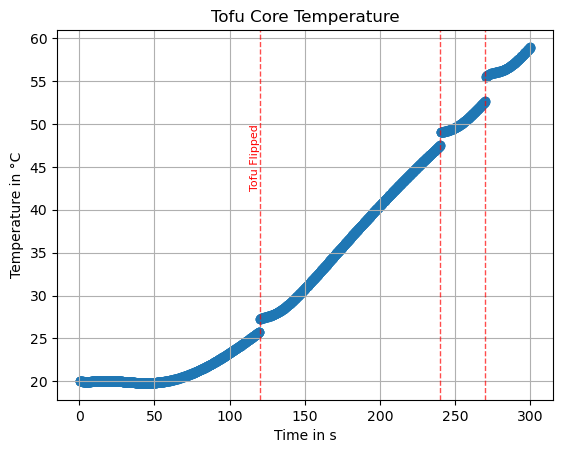

In [5]:
VP.run_simulation()